In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
products = pd.read_csv("../Dataset/Products.csv")
suppliers = pd.read_csv("../Dataset/Suppliers.csv")
warehouses = pd.read_csv("../Dataset/Warehouses.csv")
regions = pd.read_csv("../Dataset/Regions.csv")
inventory = pd.read_csv("../Dataset/Inventory.csv")
orders = pd.read_csv("../Dataset/Orders.csv")
shipments = pd.read_csv("../Dataset/Shipments.csv")

In [3]:
datasets = {
    "Products": products,
    "Suppliers": suppliers,
    "Warehouses": warehouses,
    "Regions": regions,
    "Inventory": inventory,
    "Orders": orders,
    "Shipments": shipments
}

for name, df in datasets.items():
    
    print("=" * 50)
    print(name)
    print("=" * 50)
    
    print("Shape:", df.shape)
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print("\n")

Products
Shape: (25, 6)

Missing Values:
Product_ID      0
Product_Name    0
Category        0
Unit_Cost       0
Unit_Price      0
Demand_Type     0
dtype: int64


Suppliers
Shape: (10, 6)

Missing Values:
Supplier_ID          0
Supplier_Name        0
Country              0
Reliability_Score    0
Lead_Time_Days       0
Supplier_Type        0
dtype: int64


Warehouses
Shape: (5, 6)

Missing Values:
Warehouse_ID       0
Warehourse_Name    0
Region             0
Capacity           0
Utilization        0
Warehouse_Type     0
dtype: int64


Regions
Shape: (5, 2)

Missing Values:
Region_ID      0
Region_Name    0
dtype: int64


Inventory
Shape: (25, 6)

Missing Values:
Inventory_ID        0
Product_ID          0
Warehouse_ID        0
Stock_Level         0
Reorder_Point       0
Inventory_Status    0
dtype: int64


Orders
Shape: (20000, 9)

Missing Values:
Order_ID              0
Order_Date            0
Product_ID            0
Supplier_ID           0
Warehouse_ID          0
Region_ID          

How big is Redwood Logistics?

In [4]:
print("Total Orders:", len(orders))
print("Total Revenue:", round(orders["Revenue"].sum(),2))
print("Average Order Value:", round(orders["Revenue"].mean(),2))

Total Orders: 20000
Total Revenue: 19512866
Average Order Value: 975.64


In [5]:
orders["Fulfillment_Status"].value_counts()

Fulfillment_Status
Fulfilled    17954
Delayed       1426
Pending        620
Name: count, dtype: int64

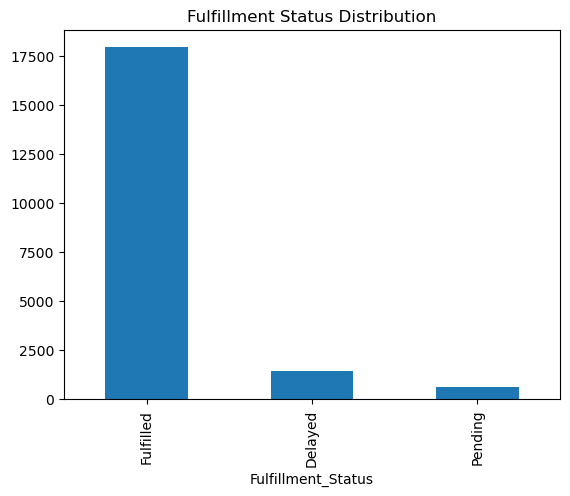

In [6]:
orders["Fulfillment_Status"].value_counts().plot(
    kind="bar"
)

plt.title("Fulfillment Status Distribution")
plt.show()

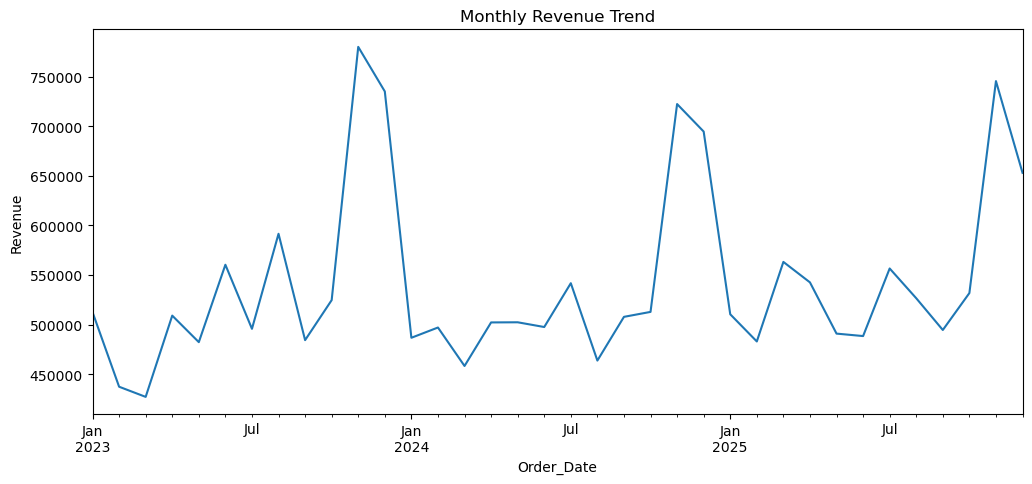

In [7]:
orders["Order_Date"] = pd.to_datetime(
    orders["Order_Date"]
)

monthly_revenue = (
    orders
    .groupby(
        orders["Order_Date"].dt.to_period("M")
    )["Revenue"]
    .sum()
)

monthly_revenue.plot(figsize=(12,5))

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")

plt.show()

# Product Intelligence Analysis

In [8]:
category_revenue = (
    orders
    .merge(products,on="Product_ID")
    .groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

Category
Electronics        7772448
Home Appliance     6353312
Furniture          2926880
Office Supplies    1528670
Personal Care       931556
Name: Revenue, dtype: int64


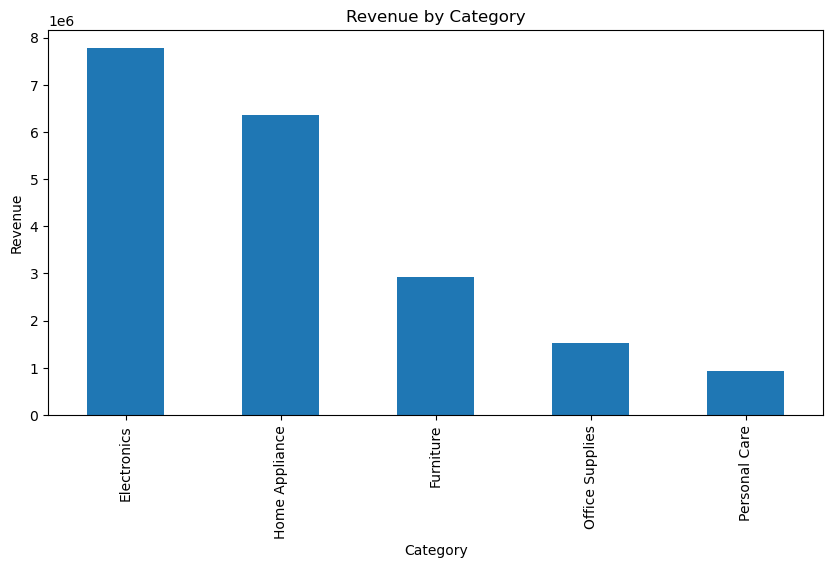

In [9]:
category_revenue.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by Category")
plt.ylabel("Revenue")

plt.show()

In [10]:
top_products = (

    orders
    .merge(products,on="Product_ID")
    .groupby("Product_Name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)

)

print(top_products)

Product_Name
CoolMax Refrigerator    2712138
Laptop Pro X            2503424
WashPro Machine         2011083
SmartPhone Elite        1990752
Tab Ultra               1603629
Vision Monitor           961009
Fkex Standing Desk       919266
Laser Printer X          734942
SmartWatch Active        713634
Study Desk Plus          697698
Name: Revenue, dtype: int64


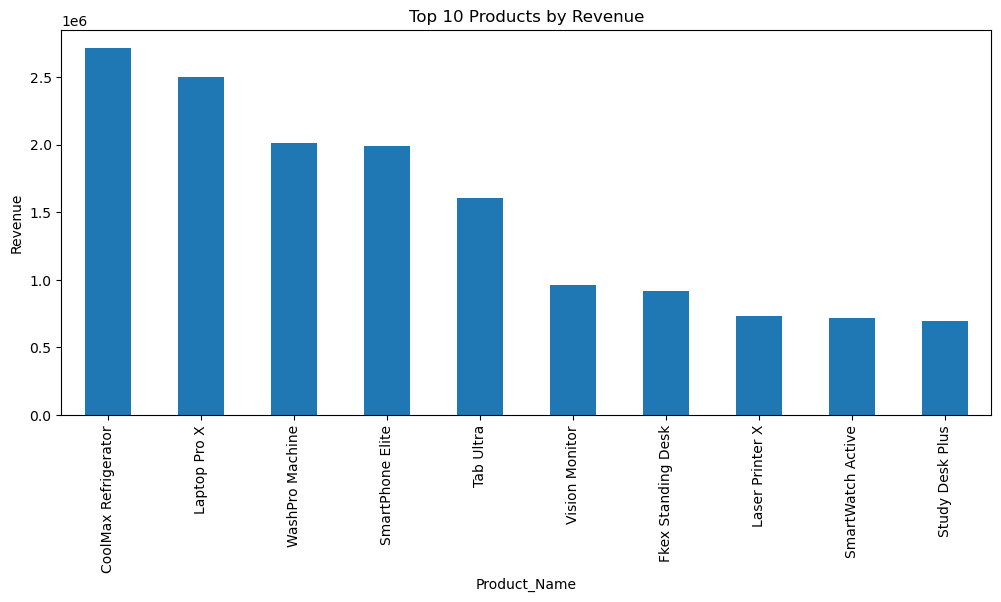

In [11]:
top_products.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")

plt.show()

# Regional Intelligence

In [12]:
region_revenue = (

    orders
    .merge(regions,on="Region_ID")
    .groupby("Region_Name")["Revenue"]
    .sum()
    .sort_values(ascending=False)

)

print(region_revenue)

Region_Name
Central    4914066
North      4160827
East       3691683
West       3470704
South      3275586
Name: Revenue, dtype: int64


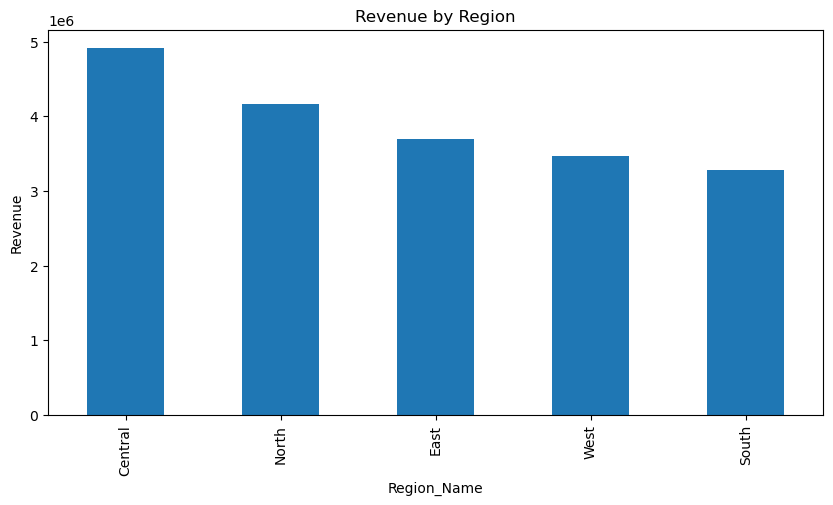

In [13]:
region_revenue.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by Region")
plt.ylabel("Revenue")

plt.show()

# Logistics Intelligence

In [14]:
shipments["Delivery_Status"].value_counts()

Delivery_Status
On-Time    17600
Delayed     2400
Name: count, dtype: int64

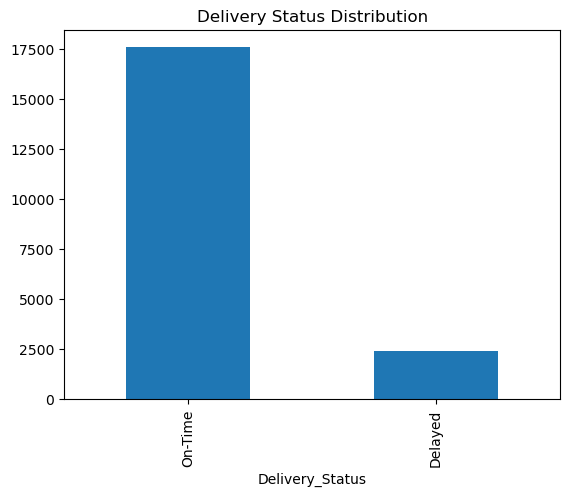

In [15]:
shipments["Delivery_Status"].value_counts().plot(
    kind="bar"
)

plt.title("Delivery Status Distribution")

plt.show()

In [16]:
shipments["Ship_Date"] = pd.to_datetime(
    shipments["Ship_Date"]
)

shipments["Delivery_Date"] = pd.to_datetime(
    shipments["Delivery_Date"]
)

shipments["Delivery_Days"] = (
    shipments["Delivery_Date"]
    - shipments["Ship_Date"]
).dt.days

print(
    shipments["Delivery_Days"].describe()
)

count    20000.000000
mean         5.580450
std          3.453002
min          1.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         14.000000
Name: Delivery_Days, dtype: float64


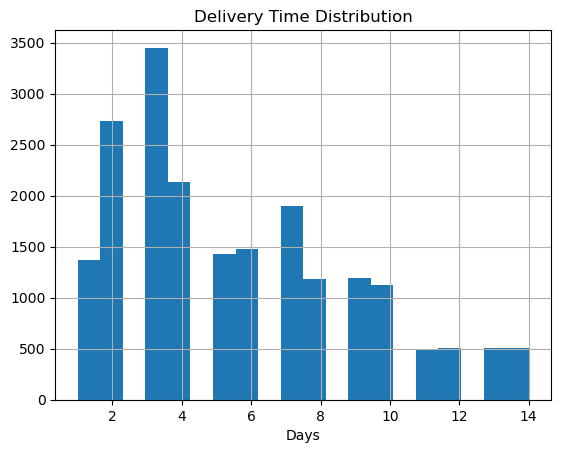

In [17]:
shipments["Delivery_Days"].hist(
    bins=20
)

plt.title("Delivery Time Distribution")
plt.xlabel("Days")

plt.show()